In [2]:
import os
import sys
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import tacco as tc
import matplotlib.pyplot as plt

# ==========================================
# 辅助函数
# ==========================================

def parse_modifications(modifications_str):
    if not modifications_str:
        return {}
    modifications = {}
    for item in modifications_str.split(','):
        try:
            key, value = item.split('=')
            modifications[key.strip()] = float(value)
        except ValueError:
            print(f"Warning: Format error in modification '{item}'. Expected key=value.")
    return modifications

def update_celltype_proportions2(df, modifications, ct='celltype'):
    celltype_proportions = df[ct].value_counts(normalize=True)
    if not modifications:
        return celltype_proportions
    
    valid_mods = {k: v for k, v in modifications.items() if k in celltype_proportions.index}
    if len(valid_mods) != len(modifications):
        missing = set(modifications.keys()) - set(celltype_proportions.index)
        print(f"Warning: Following modification keys not found in data: {missing}")

    current_remaining_proportion = celltype_proportions.drop(valid_mods.keys()).sum()
    remaining_proportion = 1 - sum(valid_mods.values())
    
    if remaining_proportion < 0:
        print("Error: Sum of modified proportions exceeds 1.0!")
        return None # 避免直接退出内核

    if current_remaining_proportion > 0:
        scale_factor = remaining_proportion / current_remaining_proportion
        celltype_proportions.update(
            celltype_proportions.drop(valid_mods.keys()) * scale_factor
        )
    celltype_proportions.update(pd.Series(valid_mods))
    return celltype_proportions

def markers_plot(adata, clust_key, df, **kwargs):
    adata = adata.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    markers = {i['celltype']: [j for j in i['marker'].split(',') if j in adata.var_names] for (_, i) in df.iterrows()}
    sc.pl.dotplot(adata, markers, groupby=clust_key, **kwargs)
    

def cluster_small_multiples(adata, clust_key, ncol=5, nrow=None, size=3, frameon=False, coord_x='x_adjust',coord_y='y_adjust', **kwargs):
    tmp = adata.copy()
    categories = adata.obs[clust_key].cat.categories
    if nrow is None:
        nrow = int(np.ceil(len(categories) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(6 * ncol, 4 * nrow))
    axs = axs.flatten()

    for i, clust in enumerate(categories):
        ax = axs[i]
        tmp.obs['__highlight__'] = (adata.obs[clust_key] == clust).astype('category')
        # 注意：这里需要确保 adata.uns 中有颜色定义，如果没有可能会报错，建议加上 try-except 或默认色
        if clust_key + '_colors' in adata.uns:
             base_color = adata.uns[clust_key + '_colors'][i]
        else:
             base_color = 'red' # Fallback color
        
        tmp.uns['__highlight___colors'] = ['#d3d3d3', base_color]
        sc.pl.scatter(tmp, basis='spatial', color='__highlight__', ax=ax, title=clust, frameon=frameon, show=False, size=size, **kwargs)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    return fig

In [3]:
# ==========================================
# 1. 参数设置 (在这里手动填写)
# ==========================================
sc_name = "M1_POD7"
chip_id = "M1_D7-Y00853K1"
base_data_dir = "/data/work/02.result/tacco_251118/00.data"
# 输出目录在调试阶段主要用于最终保存，暂时可以先定义
outdir = f"/data/work/02.result/tacco_251118/02.result/KC/1126_modification/{sc_name}"

annotation_key = 'kc_1020'
celltype_sp_key = 'pred_celltype'
selected_cells = ['KC']
min_cell_count = 20

In [4]:
# ==========================================
# 2. 路径逻辑 (保持脚本原样)
# ==========================================
if 'D21' in chip_id:
    spatial_path = f'/data/users/zengxiaoqi/zengxiaoqi_07ef1e4aa8384c83b1fbfa53cc352045/online/002.Identify_pig_cells/07.Monkey_mapping_Cluster/{chip_id}/{chip_id}_SCT.h5ad'
    print(f"D21 DETECTED. Using path: {spatial_path}")
else:
    spatial_path = os.path.join(base_data_dir, f"sp_h5ad/{chip_id}_monkey_cells_SCT.h5ad")

ref_path = os.path.join(base_data_dir, f"sc_ref_h5ad_add_M-WT/{sc_name}_anno_1111_with_MWT.h5ad")
meta_sc_path = os.path.join(base_data_dir, "all_KC_meta_1027.csv")
meta_sp_path = os.path.join(base_data_dir, f"mian_pred/pred_csv_gz/{chip_id}/pred.csv.gz")
markers_path = os.path.join(base_data_dir, "scRNA_KC_markers_for_tacco_1118.csv")

# ==========================================
# 3. 加载数据 (只运行一次)
# ==========================================
print("Loading Reference...")
reference = ad.read_h5ad(ref_path)
meta_sc = pd.read_csv(meta_sc_path, index_col=0)

# --- 您的原始逻辑 ---
cells = reference.obs_names.intersection(meta_sc.index)
reference = reference[cells, :]
reference.obs[annotation_key] = meta_sc.loc[reference.obs.index, annotation_key]
# --------------------

print("Loading Spatial...")
spatial_raw = ad.read(spatial_path) # 假设是用 read_h5ad (您脚本写的是 ad.read)
meta_sp = pd.read_csv(meta_sp_path, index_col=0)
spatial_raw.obs[celltype_sp_key] = meta_sp.loc[spatial_raw.obs.index, celltype_sp_key]
spatial_raw.X = spatial_raw.layers['counts'] 

# 坐标处理
if 'D21' in spatial_path:
    if 'spatial' in spatial_raw.obsm:
         spatial_raw.obsm['X_spatial'] = spatial_raw.obsm['spatial']
else:
    if 'x_adjust' in spatial_raw.obs and 'y_adjust' in spatial_raw.obs:
        spatial_raw.obsm['X_spatial'] = spatial_raw.obs[['x_adjust', 'y_adjust']].values
    else:
        print("Warning: x_adjust/y_adjust not found.")

# Filter Spatial
spatial_working = spatial_raw[spatial_raw.obs[celltype_sp_key].isin(selected_cells), :].copy()

# Filter Reference
table = reference.obs[annotation_key].value_counts()
removed = table[table < min_cell_count].index.tolist()
reference = reference[~reference.obs[annotation_key].isin(removed), :]
print(f"Reference filtered. Removed: {removed}")

print("✅ Data Loaded. Ready to tune.")

Loading Reference...


/tmp/ipykernel_4900/310054630.py:20: DtypeWarning: Columns (11,13,24,27,28,29,31,32,33,34,40) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_sc = pd.read_csv(meta_sc_path, index_col=0)
/tmp/ipykernel_4900/310054630.py:25: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  reference.obs[annotation_key] = meta_sc.loc[reference.obs.index, annotation_key]


Loading Spatial...


/opt/conda/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


Reference filtered. Removed: ['KC-ORS', 'KC_ACTA2']
✅ Data Loaded. Ready to tune.


## modifications 

In [17]:
# ==========================================
# 调试参数修改 (修改这里并 Shift+Enter)
# ==========================================
# 格式: "Key=Value,Key2=Value2"
current_modifications = "Spi-I=0.2"  

print(f"🔍 Testing Modifications: {current_modifications}")

🔍 Testing Modifications: Spi-I=0.2


### plot

Running Tacco Annotation...
------------------------------
👉 MSE: 0.000287
------------------------------
Top 5 Predicted vs Target:
             modified_sc  Predicted_sp
Bas-I           0.220394      0.251501
Bas-mig         0.236920      0.247179
Spi-I           0.200000      0.194478
Gra-I           0.140169      0.135414
Spi-mig         0.035305      0.048499
KC-HS           0.036207      0.034934
Sweat_Gland     0.028845      0.029172
KC-IRS          0.021934      0.027131
Bas-prolif      0.058592      0.020888
TAC             0.021634      0.010804
Generating plot...
Figure(3000x800)
✅ Plot saved to: spatial_pred_kc_1020_splitSpi-I_0.2.png

Updating spatial_raw and plotting ALL cells...
✅ All-cells plot saved to: spatial_pred_kc_1020_splitSpi-I_0.2_all.png

Analysis Done!


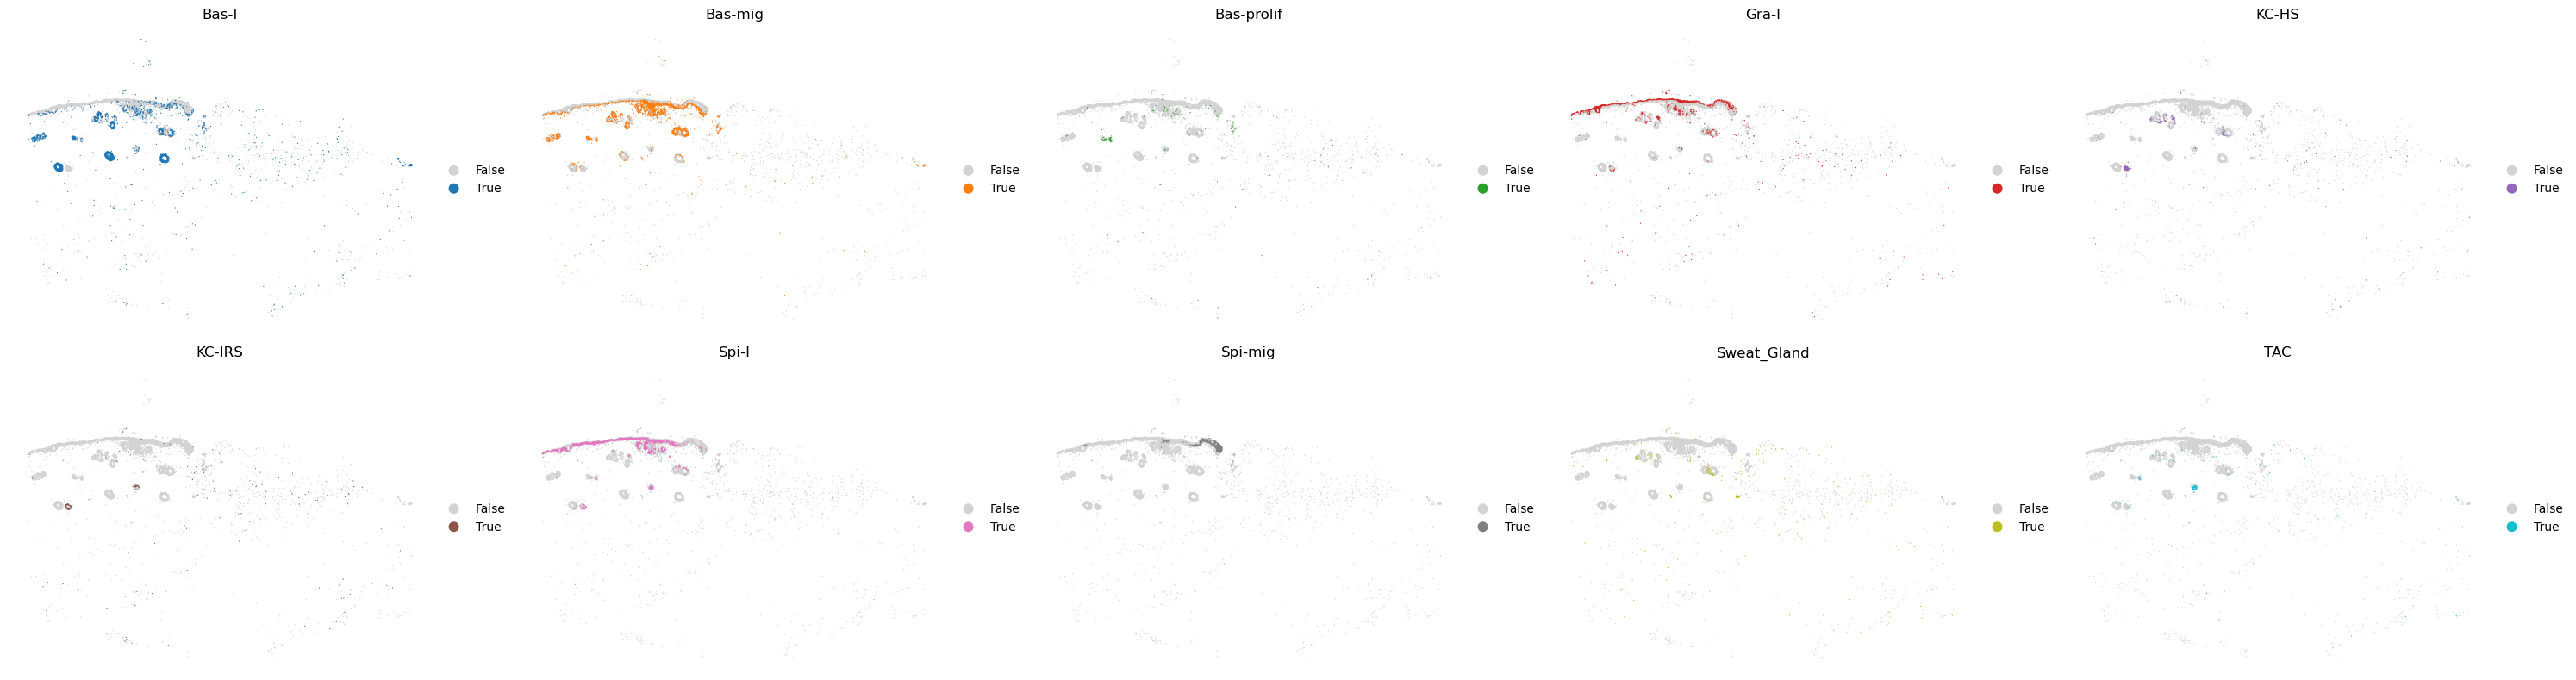

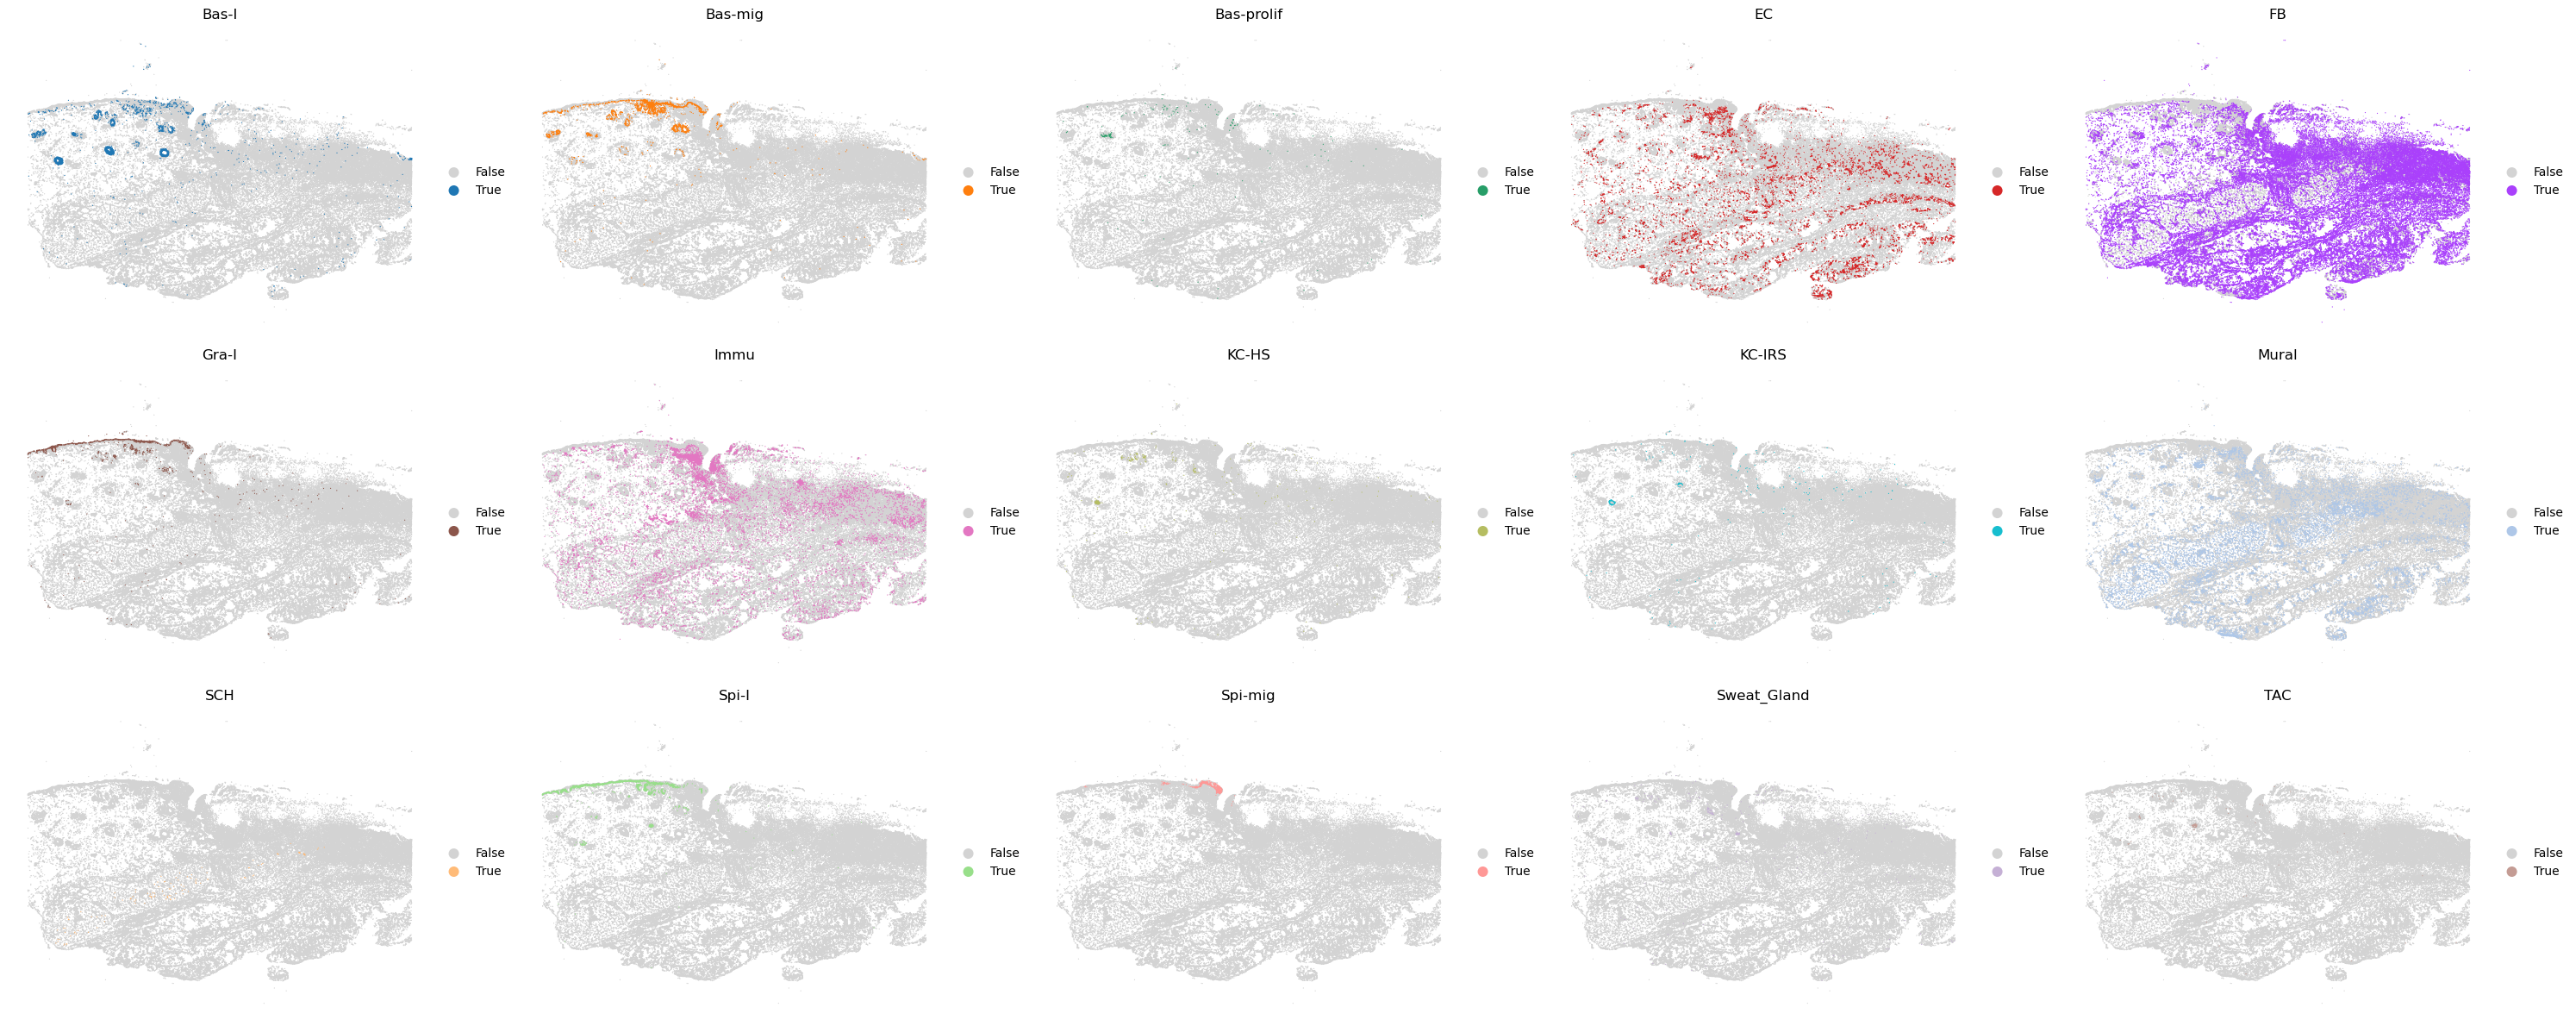

In [18]:
# 1. 计算比例
mod_dict = parse_modifications(current_modifications)
# 计算原始比例用于对比
raw_prob = reference.obs[annotation_key].value_counts(normalize=True)
# 计算修改后比例
celltype_proportions = update_celltype_proportions2(reference.obs, mod_dict, ct=annotation_key)

if celltype_proportions is not None:
    # 2. 运行 Tacco (使用副本，不影响原始数据)
    spatial_temp = spatial_working.copy()
    
    print("Running Tacco Annotation...")
    tc.tl.annotate(spatial_temp, reference, annotation_key, result_key='pred_celltype', annotation_prior=celltype_proportions, verbose=False)

    # 3. 获取预测结果
    prediction = spatial_temp.obsm['pred_celltype'].copy()
    prediction_cls = prediction.idxmax(1)
    
    # --- 【关键修复点 1】: 将预测结果写回 .obs 并转为 category ---
    celltype_col = 'pred_celltype' # 定义列名变量
    spatial_temp.obs[celltype_col] = prediction_cls.astype('category') # 必须转为 category 类型
    
    # 4. MSE 计算 (核心评估指标)
    pred_prob = prediction_cls.value_counts(normalize=True)
    common_idx = pred_prob.index.intersection(celltype_proportions.index)
    mse = ((pred_prob[common_idx] - celltype_proportions[common_idx]) ** 2).mean()
    
    print("-" * 30)
    print(f"👉 MSE: {mse:.6f}")
    print("-" * 30)
    
    # 5. 可选：快速看一眼分布对比 (Text)
    print("Top 5 Predicted vs Target:")
    compare_df = pd.DataFrame({'modified_sc': celltype_proportions, 'Predicted_sp': pred_prob}).fillna(0)
    print(compare_df.sort_values('Predicted_sp', ascending=False).head(13))

    # --- 绘图部分 ---
    print("Generating plot...")
    
    
    ## --- 【新增/修改】 文件名安全处理逻辑 ---

    # 1. 判断并清理特殊字符
    if current_modifications:
        # 如果字符串非空，则进行清理
        cleaned_modifications = current_modifications.replace("=", "_").replace(",", "_")
    else:
        # 如果是空字符串，则直接将清理后的结果设为空字符串
        cleaned_modifications = "" 

    # 2. 构建后缀：只有 cleaned_modifications 非空时，safe_mod_suffix 才包含下划线
    safe_mod_name = f"_{cleaned_modifications}" if cleaned_modifications else ""
    
    
    
    try:
        # Plot 1: Spatial scatter (subset)
    
        # 为了让 cluster_small_multiples 里的颜色逻辑正常工作，最好先跑一次 scanpy 的默认 scatter 生成颜色，否则它会全部变成红色 (Fallback color)
        sc.pl.scatter(spatial_temp, basis='spatial', color=celltype_col, show=False) 
        plt.savefig(f"pred_{annotation_key}{safe_mod_name}.png")
        plt.close()
        
        fig = cluster_small_multiples(spatial_temp, clust_key=celltype_col, frameon=False)
        print(fig)

        # Plot 2: Split (subset)      
        safe_mod_name = current_modifications.replace("=", "_").replace(",", "_")
        save_path = f"spatial_pred_{annotation_key}_split{safe_mod_name}.png"
        fig.savefig(save_path, dpi=200)
        print(f"✅ Plot saved to: {save_path}")
        #plt.close(fig) # 关闭画布防止在 notebook 中显示过多
        
    except Exception as e:
        import traceback
        traceback.print_exc() # 打印完整报错信息以便排查
        print(f"❌ Error plotting split subset: {e}")
        
        
        
    # =========================================================
    # 新增：将预测结果映射回 spatial_raw 并绘制全部细胞
    # =========================================================
    print("\nUpdating spatial_raw and plotting ALL cells...")
    
    try:
        
        # Plot 3: Spatial scatter (all)
        sc.pl.scatter(spatial_raw, basis='spatial', color=celltype_col, show=False)
        plt.savefig(f"pred_{annotation_key}{safe_mod_name}_all.png")
        plt.close()
        
        
        # Plot 4: Split (ALL) 
        # 1. 确保 spatial_raw 中列的数据类型是 object (以便可以修改)
        # 如果是 category 类型，直接赋值新字符串可能会报错，所以先转 object
        if celltype_col in spatial_raw.obs:
             spatial_raw.obs[celltype_col] = spatial_raw.obs[celltype_col].astype(object)
        else:
             # 如果不存在，可能需要从原始 metadata 列初始化 (假设 celltype_sp_key 存着原始大类)
             spatial_raw.obs[celltype_col] = spatial_raw.obs[celltype_sp_key].astype(object)

        # 2. 将本次 Tacco 预测的结果 (KC subset) 更新到 spatial_raw 中
        # spatial_temp.obs_names 是 KC 细胞的索引
        spatial_raw.obs.loc[spatial_temp.obs_names, celltype_col] = prediction_cls

        # 3. 再次转回 category (绘图函数要求)
        spatial_raw.obs[celltype_col] = spatial_raw.obs[celltype_col].astype('category')

        # 4. 绘图 (All cells)
        fig_all = cluster_small_multiples(spatial_raw, clust_key=celltype_col, frameon=False)
        # print(fig_all)

        save_path_all = f"spatial_pred_{annotation_key}_split{safe_mod_name}_all.png"
        fig_all.savefig(save_path_all, dpi=200)
        print(f"✅ All-cells plot saved to: {save_path_all}")
        # plt.close(fig_all)

    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"❌ Error plotting split all: {e}")

    print("\nAnalysis Done!")
        
        
else:
    print("❌ Failed to calculate proportions.")